In [9]:
###### DON'T USE IT, CRASHES AFTER RUNNING FOR MORE THAN AN HOUR

# from datasets import load_dataset

# # Login using e.g. `huggingface-cli login` to access this dataset
# ds = load_dataset("AisotTechnologies/aisot_btc_lob_trades")

In [10]:
###### USE THIS METHOD INSTEAD

# from huggingface_hub import snapshot_download

# snapshot_download(repo_id="AisotTechnologies/aisot_btc_lob_trades", allow_patterns="*.zip", local_dir='data/', repo_type='dataset')

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [13]:
import os
from datasets import load_dataset

# Define the folder containing the ZIP files
data_folder = "./data/"

# Get all ZIP files containing "trx" in the filename
ob_zip_files = [
    os.path.join(data_folder, f) for f in os.listdir(data_folder) 
    if "ob" in f and f.endswith(".zip")
]

# Ensure that matching files were found
if not ob_zip_files:
    raise FileNotFoundError("No matching 'ob' ZIP files found in './data/'.")

# Load dataset using Hugging Face `load_dataset`
ob_dataset_raw = load_dataset("csv", data_files=ob_zip_files[1])  # Adjust to "parquet" if needed
ob_dataset_raw


Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['time', 'type', 'price', 'amount '],
        num_rows: 25104741
    })
})

In [14]:
ob_dataset = ob_dataset_raw['train'].to_pandas()

df = ob_dataset[ob_dataset['time'] == 1533333601]
df = df.rename(columns={'amount ': 'amount'})

#plot the order book data which columns on different price levels

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming your data is loaded into a DataFrame called 'df'
# Example data loading (replace with your actual data source):
# df = pd.read_csv('orderbook.csv')

# Separate bids and asks
bids = df[df['type'] == 'b'].sort_values('price', ascending=False)
asks = df[df['type'] == 'a'].sort_values('price', ascending=True)




In [15]:
# drop the maximum price from the bids and the minimum price from the asks
bids = bids[bids['price'] != bids['price'].min()]
asks = asks[asks['price'] != asks['price'].max()]
# drop every bid which price is less than 1
bids = bids[bids['price'] > 10]


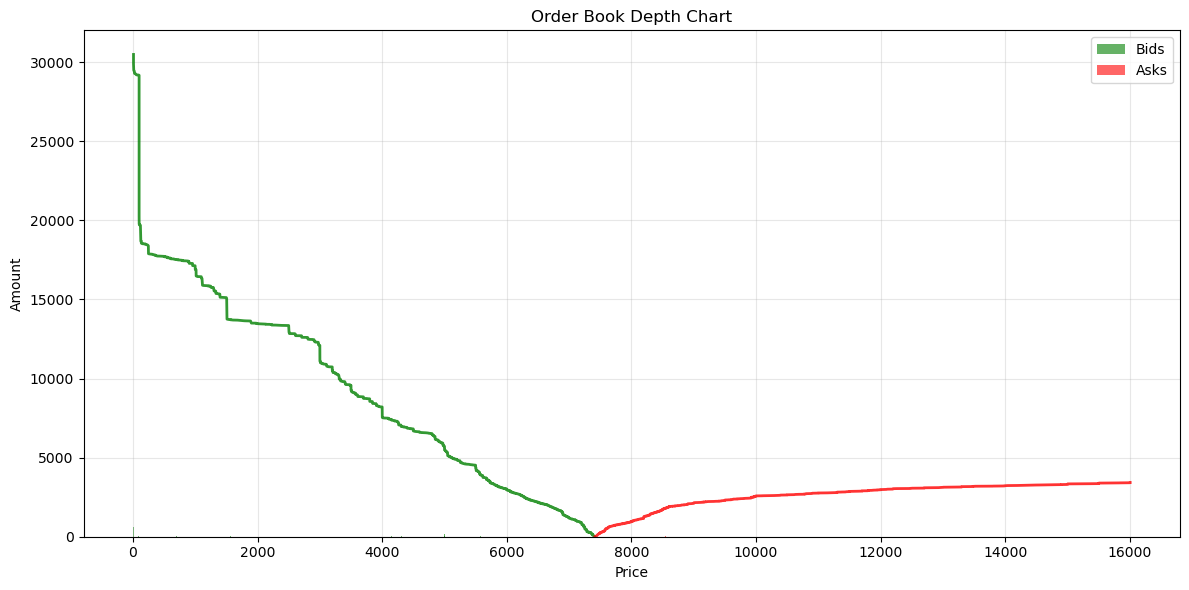

In [16]:
# Create cumulative amounts
bids['cum_amount'] = bids['amount'].cumsum()
asks['cum_amount'] = asks['amount'].cumsum()

# Create the plot
plt.figure(figsize=(12, 6))

# Plot bids (buy orders)
plt.bar(bids['price'], bids['amount'], width=0.6, 
        color='green', alpha=0.6, label='Bids')

# Plot asks (sell orders)
plt.bar(asks['price'], asks['amount'], width=0.6, 
        color='red', alpha=0.6, label='Asks')

# Add cumulative amount lines
plt.plot(bids['price'], bids['cum_amount'], 'g-', linewidth=2, alpha=0.8)
plt.plot(asks['price'], asks['cum_amount'], 'r-', linewidth=2, alpha=0.8)

# Add labels and title
plt.xlabel('Price')
plt.ylabel('Amount')
plt.title('Order Book Depth Chart')
plt.legend()

# Add grid and adjust layout
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()


In [21]:
def calculate_impact(df, units_to_buy):
    # Separate bids and asks
    bids = df[df['type'] == 'b'].sort_values('price', ascending=False)
    asks = df[df['type'] == 'a'].sort_values('price', ascending=True)

    # Filter out bids below 10
    bids = bids[bids['price'] > 10]

    # Calculate mid price (average of best bid and best ask)
    if not asks.empty and not bids.empty:
        mid_price = (asks['price'].iloc[0] + bids['price'].iloc[0]) / 2
    else:
        return 0, 0  # Return 0 if no valid bids or asks

    # Calculate total ask volume and cumulative volume at each price level
    asks['cum_volume'] = asks['amount'].cumsum()
    total_ask_volume = asks['amount'].sum()

    # Find how many price levels we need to cover X units
    remaining_units = units_to_buy
    extra_cost = 0
    volume_filled = 0

    for index, row in asks.iterrows():
        if remaining_units <= 0:
            break
            
        # Calculate how many units we can take from this price level
        volume_at_price = min(remaining_units, row['amount'])
        
        # Add to extra cost (price difference from mid)
        extra_cost += volume_at_price * (row['price'] - mid_price)
        volume_filled += volume_at_price
        remaining_units -= volume_at_price

    # Calculate average extra cost per unit
    if volume_filled > 0:
        average_extra_cost = extra_cost / volume_filled
    else:
        average_extra_cost = 0

    return average_extra_cost

# Example usage
units_to_buy = 1000  # Specify how many units you want to buy
extra_cost = calculate_impact(df, units_to_buy)
print(f"Average extra cost compared to mid price when buying {units_to_buy} units: {extra_cost}")

#NOW FOR SELLING

def calculate_impact_sell(df, units_to_sell):
    # Separate bids and asks
    bids = df[df['type'] == 'b'].sort_values('price', ascending=False)
    asks = df[df['type'] == 'a'].sort_values('price', ascending=True)

    # Calculate mid price (average of best bid and best ask)
    if not asks.empty and not bids.empty:
        mid_price = (asks['price'].iloc[0] + bids['price'].iloc[0]) / 2
    else:
        return 0, 0  # Return 0 if no valid bids or asks

    # Calculate total bid volume and cumulative volume at each price level
    bids['cum_volume'] = bids['amount'].cumsum()
    total_bid_volume = bids['amount'].sum()

    # Find how many price levels we need to cover X units
    remaining_units = units_to_sell
    extra_cost = 0
    volume_filled = 0

    for index, row in bids.iterrows():
        if remaining_units <= 0:
            break
            
        # Calculate how many units we can take from this price level
        volume_at_price = min(remaining_units, row['amount'])
        
        # Add to extra cost (price difference from mid)
        extra_cost += volume_at_price * (mid_price - row['price'])
        volume_filled += volume_at_price
        remaining_units -= volume_at_price

    # Calculate average extra cost per unit
    if volume_filled > 0:
        average_extra_cost = extra_cost / volume_filled
    else:
        average_extra_cost = 0

    return average_extra_cost

# Example usage
units_to_sell = 1000  # Specify how many units you want to sell
extra_cost_sell = calculate_impact_sell(df, units_to_sell)
print(f"Average extra cost compared to mid price when selling {units_to_sell} units: {extra_cost_sell}")

Average extra cost compared to mid price when buying 1000 units: 236.5423631370379
Average extra cost compared to mid price when selling 1000 units: 139.16837100936604
